<a href="https://colab.research.google.com/github/MarianaCelisBougard/Taller_NNA_Grupo4/blob/main/Data_Preparation/Data_Preparation_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
# -*- coding: utf-8 -*-
"""
==============================================================================
CRISP-DM FASE 3: DATA PREPARATION (VERSIÓN ADAPTADA A ESTRUCTURA REAL)
Proyecto: Caracterización de NNA en Programas de Intervención
Notebook 2 de 2 - Preparación Avanzada de Datos
==============================================================================
"""
# ==============================================================================
# 1. CONFIGURACIÓN INICIAL Y CARGA DE LIBRERÍAS
# ==============================================================================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from scipy import sparse
import warnings
import os
warnings.filterwarnings('ignore')

# Configuración visual
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)

print("=" * 80)
print("CRISP-DM FASE 3: DATA PREPARATION (VERSIÓN CORREGIDA)")
print("Proyecto: Caracterización de NNA en Trabajo Infantil")
print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CRISP-DM FASE 3: DATA PREPARATION (VERSIÓN CORREGIDA)
Proyecto: Caracterización de NNA en Trabajo Infantil
Fecha de ejecución: 2025-10-16 01:56:36


In [93]:
# ==============================================================================
# 2. FUNCIONES AUXILIARES
# ==============================================================================

def buscar_columna(df, palabras_clave):
    """Busca columna por palabras clave (ignora mayúsculas)"""
    cols_upper = {col.upper().strip(): col for col in df.columns}
    for palabra in palabras_clave:
        for col_upper, col_original in cols_upper.items():
            if palabra.upper() in col_upper:
                return col_original
    return None

In [94]:
# ==============================================================================
# 3. CARGA DE DATOS FILTRADOS
# ==============================================================================

ruta = '/content/drive/MyDrive/Python/Proyecto NNA/datos_filtrados.xlsx'

print("\n📂 Cargando datos filtrados desde Notebook 1...")
try:
    datos = pd.read_excel(ruta, sheet_name='Datos_filtrados')
    print(f"✅ Datos cargados exitosamente")
    print(f"   - Shape inicial: {datos.shape[0]:,} registros × {datos.shape[1]} columnas")
except FileNotFoundError:
    print("❌ ERROR: Ejecuta primero el Notebook 1 (EDA)")
    raise


📂 Cargando datos filtrados desde Notebook 1...
✅ Datos cargados exitosamente
   - Shape inicial: 56,473 registros × 28 columnas


In [95]:
# ==============================================================================
# 4. DIAGNÓSTICO INICIAL
# ==============================================================================

print("\n" + "=" * 80)
print("🔍 DIAGNÓSTICO INICIAL")
print("=" * 80)

cat_cols = datos.select_dtypes(include='object').columns.tolist()
num_cols = datos.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n📊 Composición:")
print(f"   - Categóricas: {len(cat_cols)}")
print(f"   - Numéricas: {len(num_cols)}")
print(f"   - Total: {len(datos.columns)}")

print(f"\n⚠️  Valores faltantes:")
missing = datos.isna().sum()
vars_con_missing = missing[missing > 0].sort_values(ascending=False)
if len(vars_con_missing) > 0:
    print(f"   Variables con faltantes: {len(vars_con_missing)}")
    for var, count in vars_con_missing.head(5).items():
        pct = (count / len(datos)) * 100
        print(f"      - {var}: {count:,} ({pct:.1f}%)")
else:
    print(f"   ✅ No hay valores faltantes")


🔍 DIAGNÓSTICO INICIAL

📊 Composición:
   - Categóricas: 22
   - Numéricas: 2
   - Total: 28

⚠️  Valores faltantes:
   Variables con faltantes: 20
      - INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO: 33,669 (59.6%)
      - FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE: 29,980 (53.1%)
      - ESTRATO: 28,141 (49.8%)
      - MANZANA DEL CUIDADO: 28,141 (49.8%)
      - BARRIO PRIORIZADO: 28,140 (49.8%)


In [96]:
# ==============================================================================
# 5. FEATURE ENGINEERING - CREACIÓN DE VARIABLES NUMÉRICAS
# ==============================================================================

print("\n" + "=" * 80)
print("🔨 FEATURE ENGINEERING - CREACIÓN DE VARIABLES DERIVADAS")
print("=" * 80)

nuevas_numericas = []

# ============================================================
# Feature 1: EDAD_RANGO (Ordinal)
# ============================================================
edad_col = buscar_columna(datos, ['EDAD'])
if edad_col:
    print(f"\n1️⃣ Creando EDAD_RANGO desde '{edad_col}'")
    try:
        datos['EDAD_RANGO'] = pd.cut(
            datos[edad_col],
            bins=[0, 5, 11, 14, 18],
            labels=[1, 2, 3, 4],
            include_lowest=True
        ).astype(float)

        # Imputar faltantes con valor medio
        datos['EDAD_RANGO'].fillna(2, inplace=True)

        nuevas_numericas.append('EDAD_RANGO')
        print(f"   ✅ Creada: EDAD_RANGO")
        print(f"      Rangos: 1=[0-5], 2=[6-11], 3=[12-14], 4=[15-18]")
        print(f"      Distribución:\n{datos['EDAD_RANGO'].value_counts().sort_index()}")
    except Exception as e:
        print(f"   ⚠️ Error: {e}")

# ============================================================
# Feature 2: ÍNDICE DE VULNERABILIDAD (0-10)
# ============================================================
print(f"\n2️⃣ Creando INDICE_VULNERABILIDAD")

datos['INDICE_VULNERABILIDAD'] = 0.0
factores_aplicados = []

# Factor 1: Estrato bajo
estrato_col = buscar_columna(datos, ['ESTRATO SOCIOECONÓMICO', 'ESTRATO'])
if estrato_col:
    estratos_bajos = ['1. Bajo-bajo', '2. Bajo', '1', '2', 'Bajo-bajo', 'Bajo']
    es_bajo = datos[estrato_col].astype(str).isin(estratos_bajos)
    datos.loc[es_bajo, 'INDICE_VULNERABILIDAD'] += 3
    factores_aplicados.append(f"Estrato bajo (+3): {es_bajo.sum()} casos")

# Factor 2: Población diferencial
pob_dif_col = buscar_columna(datos, ['POBLACIÓN DIFERENCIAL'])
if pob_dif_col:
    valores_neutros = ['14- No Aplica', 'No aplica', '14-No Aplica', 'No_reporta']
    es_diferencial = ~datos[pob_dif_col].astype(str).isin(valores_neutros)
    datos.loc[es_diferencial, 'INDICE_VULNERABILIDAD'] += 2
    factores_aplicados.append(f"Población diferencial (+2): {es_diferencial.sum()} casos")

# Factor 3: Discapacidad
discap_col = buscar_columna(datos, ['CATEGORÍAS DE LA DISCAPACIDAD', 'DISCAPACIDAD'])
if discap_col:
    valores_neutros = ['No aplica', '6- Ninguno', 'Ninguno', 'No_reporta']
    tiene_discap = ~datos[discap_col].astype(str).isin(valores_neutros)
    datos.loc[tiene_discap, 'INDICE_VULNERABILIDAD'] += 2
    factores_aplicados.append(f"Discapacidad (+2): {tiene_discap.sum()} casos")

# Factor 4: Sin afiliación a salud
afil_col = buscar_columna(datos, ['AFILIACIÓN AL SGSSS'])
if afil_col:
    sin_afil = datos[afil_col].astype(str).str.contains('No asegurado|5-', case=False, na=False)
    datos.loc[sin_afil, 'INDICE_VULNERABILIDAD'] += 1
    factores_aplicados.append(f"Sin afiliación salud (+1): {sin_afil.sum()} casos")

# Factor 5: Barrio priorizado
barrio_col = buscar_columna(datos, ['BARRIO PRIORIZADO'])
if barrio_col:
    es_prioritario = datos[barrio_col].astype(str).isin(['Si', 'Sí', 'SI'])
    datos.loc[es_prioritario, 'INDICE_VULNERABILIDAD'] += 1
    factores_aplicados.append(f"Barrio priorizado (+1): {es_prioritario.sum()} casos")

# Factor 6: Edad muy temprana
if edad_col:
    edad_temprana = datos[edad_col] <= 5
    datos.loc[edad_temprana, 'INDICE_VULNERABILIDAD'] += 1
    factores_aplicados.append(f"Edad ≤5 años (+1): {edad_temprana.sum()} casos")

nuevas_numericas.append('INDICE_VULNERABILIDAD')
print(f"   ✅ INDICE_VULNERABILIDAD creado")
print(f"      Factores aplicados: {len(factores_aplicados)}")
for factor in factores_aplicados:
    print(f"         • {factor}")
print(f"      Rango: {datos['INDICE_VULNERABILIDAD'].min():.0f} - {datos['INDICE_VULNERABILIDAD'].max():.0f}")
print(f"      Media: {datos['INDICE_VULNERABILIDAD'].mean():.2f}")
print(f"      Distribución:\n{datos['INDICE_VULNERABILIDAD'].value_counts().sort_index()}")

# ============================================================
# Feature 3: COMPLEJIDAD_CASO (Conteo)
# ============================================================
print(f"\n3️⃣ Creando COMPLEJIDAD_CASO")

datos['COMPLEJIDAD_CASO'] = 0

# Contar factores de complejidad
if pob_dif_col:
    es_complejo = ~datos[pob_dif_col].astype(str).isin(['14- No Aplica', 'No aplica', 'No_reporta'])
    datos.loc[es_complejo, 'COMPLEJIDAD_CASO'] += 1

if discap_col:
    tiene_discap = ~datos[discap_col].astype(str).isin(['No aplica', '6- Ninguno', 'No_reporta'])
    datos.loc[tiene_discap, 'COMPLEJIDAD_CASO'] += 1

desvinc_col = buscar_columna(datos, ['NNA DESVINCULADO'])
if desvinc_col:
    no_desvinculado = datos[desvinc_col].astype(str).isin(['No', 'NO'])
    datos.loc[no_desvinculado, 'COMPLEJIDAD_CASO'] += 1

nuevas_numericas.append('COMPLEJIDAD_CASO')
print(f"   ✅ COMPLEJIDAD_CASO creada")
print(f"      Rango: {datos['COMPLEJIDAD_CASO'].min()} - {datos['COMPLEJIDAD_CASO'].max()}")
print(f"      Distribución:\n{datos['COMPLEJIDAD_CASO'].value_counts().sort_index()}")

# ============================================================
# Feature 4: TRABAJO_ACTIVO (Binario)
# ============================================================
trabajo_col = buscar_columna(datos, ['EN DONDE REALIZA', 'TRABAJO'])
if trabajo_col:
    print(f"\n4️⃣ Creando TRABAJO_ACTIVO")
    datos['TRABAJO_ACTIVO'] = datos[trabajo_col].notna().astype(int)
    nuevas_numericas.append('TRABAJO_ACTIVO')

    print(f"   ✅ TRABAJO_ACTIVO creada")
    print(f"      Trabaja: {datos['TRABAJO_ACTIVO'].sum():,} ({datos['TRABAJO_ACTIVO'].mean()*100:.1f}%)")
    print(f"      No trabaja: {(1-datos['TRABAJO_ACTIVO']).sum():,}")

# ============================================================
# Feature 5: ANTIGUEDAD_DIAS (CORREGIDO)
# ============================================================
print(f"\n5️⃣ Creando ANTIGUEDAD_DIAS")

fecha_col = buscar_columna(datos, ['FECHA'])
if fecha_col:
    try:
        # Convertir a datetime con manejo robusto
        datos[fecha_col] = pd.to_datetime(datos[fecha_col], errors='coerce')

        # Fecha de referencia
        fecha_ref = pd.Timestamp.now()

        # Calcular antigüedad
        datos['ANTIGUEDAD_DIAS'] = (fecha_ref - datos[fecha_col]).dt.days

        # CORRECCIÓN CRÍTICA: Validar rangos
        # Solo fechas válidas (no futuras, no anteriores a 2020)
        fecha_min = pd.Timestamp('2020-01-01')
        datos.loc[datos[fecha_col] < fecha_min, 'ANTIGUEDAD_DIAS'] = np.nan
        datos.loc[datos[fecha_col] > fecha_ref, 'ANTIGUEDAD_DIAS'] = np.nan

        # Imputar faltantes con mediana
        mediana_antig = datos['ANTIGUEDAD_DIAS'].median()
        datos['ANTIGUEDAD_DIAS'].fillna(mediana_antig, inplace=True)

        # Asegurar valores positivos
        datos['ANTIGUEDAD_DIAS'] = datos['ANTIGUEDAD_DIAS'].clip(lower=0)

        nuevas_numericas.append('ANTIGUEDAD_DIAS')

        print(f"   ✅ ANTIGUEDAD_DIAS creada")
        print(f"      Rango: {datos['ANTIGUEDAD_DIAS'].min():.0f} - {datos['ANTIGUEDAD_DIAS'].max():.0f} días")
        print(f"      Promedio: {datos['ANTIGUEDAD_DIAS'].mean():.0f} días (~{datos['ANTIGUEDAD_DIAS'].mean()/365:.1f} años)")
        print(f"      Mediana: {datos['ANTIGUEDAD_DIAS'].median():.0f} días")

    except Exception as e:
        print(f"   ⚠️ Error al crear ANTIGUEDAD_DIAS: {e}")
        print(f"      Continuando sin esta variable")
else:
    print(f"   ⚠️ No se encontró columna de fecha")

# Actualizar lista de columnas numéricas
num_cols = datos.select_dtypes(include=[np.number]).columns.tolist()

print(f"\n" + "=" * 80)
print(f"✅ RESUMEN FEATURE ENGINEERING")
print(f"=" * 80)
print(f"   Variables numéricas NUEVAS creadas: {len(nuevas_numericas)}")
print(f"   Variables numéricas TOTALES: {len(num_cols)}")
print(f"\n   Listado completo:")
for col in num_cols:
    print(f"      ✓ {col}")



🔨 FEATURE ENGINEERING - CREACIÓN DE VARIABLES DERIVADAS

1️⃣ Creando EDAD_RANGO desde 'EDAD'
   ✅ Creada: EDAD_RANGO
      Rangos: 1=[0-5], 2=[6-11], 3=[12-14], 4=[15-18]
      Distribución:
EDAD_RANGO
1.000     8407
2.000    37675
3.000     5946
4.000     4445
Name: count, dtype: int64

2️⃣ Creando INDICE_VULNERABILIDAD
   ✅ INDICE_VULNERABILIDAD creado
      Factores aplicados: 6
         • Estrato bajo (+3): 35969 casos
         • Población diferencial (+2): 5194 casos
         • Discapacidad (+2): 173 casos
         • Sin afiliación salud (+1): 6907 casos
         • Barrio priorizado (+1): 4417 casos
         • Edad ≤5 años (+1): 8407 casos
      Rango: 0 - 9
      Media: 2.45
      Distribución:
INDICE_VULNERABILIDAD
0.000    17047
1.000     2143
2.000      680
3.000    21439
4.000     9356
5.000     2937
6.000     1844
7.000      844
8.000      176
9.000        7
Name: count, dtype: int64

3️⃣ Creando COMPLEJIDAD_CASO
   ✅ COMPLEJIDAD_CASO creada
      Rango: 0 - 3
      Distrib

In [97]:
# ==============================================================================
# 6. IMPUTACIÓN DE VALORES FALTANTES (CORREGIDO)
# ==============================================================================

print("\n" + "=" * 80)
print("🧹 IMPUTACIÓN DE VALORES FALTANTES")
print("=" * 80)

# Identificar columnas por tipo
num_cols = datos.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = datos.select_dtypes(include='object').columns.tolist()

# CORRECCIÓN CRÍTICA: Excluir columnas de fecha de la imputación
fecha_keywords = ['FECHA', 'DATE', 'TIMESTAMP', 'CIERRE', 'INGRESO']
num_cols_sin_fechas = [col for col in num_cols
                       if not any(keyword in col.upper() for keyword in fecha_keywords)]

print(f"\n📋 Clasificación de variables:")
print(f"   - Numéricas totales: {len(num_cols)}")
print(f"   - Numéricas (sin fechas): {len(num_cols_sin_fechas)}")
print(f"   - Categóricas: {len(cat_cols)}")

# Verificar si se excluyeron columnas
cols_excluidas = [col for col in num_cols if col not in num_cols_sin_fechas]
if cols_excluidas:
    print(f"\n⚠️  Columnas de fecha EXCLUIDAS de imputación:")
    for col in cols_excluidas:
        print(f"      - {col}")

# 6.1 Imputación de numéricas (SIN fechas)
print(f"\n📊 Variables NUMÉRICAS (sin fechas):")
missing_num_antes = datos[num_cols_sin_fechas].isna().sum().sum()
print(f"   Valores faltantes antes: {missing_num_antes:,}")

if missing_num_antes > 0:
    imputer_num = SimpleImputer(strategy='median')
    datos[num_cols_sin_fechas] = imputer_num.fit_transform(datos[num_cols_sin_fechas])
    print(f"   ✅ Imputación por mediana completada")

missing_num_despues = datos[num_cols_sin_fechas].isna().sum().sum()
print(f"   Valores faltantes después: {missing_num_despues}")

# 6.2 Imputación de categóricas
print(f"\n📝 Variables CATEGÓRICAS:")
missing_cat_antes = datos[cat_cols].isna().sum().sum()
print(f"   Valores faltantes antes: {missing_cat_antes:,}")

if missing_cat_antes > 0:
    for col in cat_cols:
        if datos[col].isna().sum() > 0:
            datos[col].fillna("No_reporta", inplace=True)
    print(f"   ✅ Imputación con 'No_reporta' completada")

missing_cat_despues = datos[cat_cols].isna().sum().sum()
print(f"   Valores faltantes después: {missing_cat_despues}")

# 6.3 VERIFICACIÓN FINAL (INCLUYE TODAS LAS COLUMNAS)
print(f"\n🔍 VERIFICACIÓN COMPLETA DEL DATASET:")
total_faltantes = datos.isna().sum().sum()
print(f"   ✅ Total valores faltantes en TODO el dataset: {total_faltantes}")

if total_faltantes > 0:
    print(f"\n⚠️  Variables con faltantes restantes:")
    vars_con_faltantes = datos.isna().sum()
    vars_con_faltantes = vars_con_faltantes[vars_con_faltantes > 0].sort_values(ascending=False)
    for var, count in vars_con_faltantes.items():
        pct = (count / len(datos)) * 100
        print(f"      - {var}: {count:,} ({pct:.1f}%)")

    # DECISIÓN: ¿Eliminar columnas de fecha con faltantes?
    if len(cols_excluidas) > 0:
        print(f"\n📅 Columnas de fecha con faltantes (NO se imputarán):")
        for col in cols_excluidas:
            if col in datos.columns and datos[col].isna().sum() > 0:
                faltantes = datos[col].isna().sum()
                pct = (faltantes / len(datos)) * 100
                print(f"      - {col}: {faltantes:,} ({pct:.1f}%)")
                print(f"         → Se ELIMINARÁ esta columna (no es necesaria para clustering)")
                datos.drop(columns=[col], inplace=True)

        print(f"\n✅ Columnas de fecha eliminadas del dataset")


🧹 IMPUTACIÓN DE VALORES FALTANTES

📋 Clasificación de variables:
   - Numéricas totales: 7
   - Numéricas (sin fechas): 7
   - Categóricas: 22

📊 Variables NUMÉRICAS (sin fechas):
   Valores faltantes antes: 34,380
   ✅ Imputación por mediana completada
   Valores faltantes después: 0

📝 Variables CATEGÓRICAS:
   Valores faltantes antes: 273,441
   ✅ Imputación con 'No_reporta' completada
   Valores faltantes después: 0

🔍 VERIFICACIÓN COMPLETA DEL DATASET:
   ✅ Total valores faltantes en TODO el dataset: 41207

⚠️  Variables con faltantes restantes:
      - FECHA - REPOSICIÓN DE PSICÓLOGO O TRABAJADOR SOCIAL POSTERIOR AL SEGUIMIENTO - CIERRE: 29,980 (53.1%)
      - FECHA DE NACIMIENTO: 11,180 (19.8%)
      - FECHA - SEGUIMIENTO CIERRE: 47 (0.1%)


In [98]:
# ==============================================================================
# 7. VALIDACIÓN PRE-CODIFICACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print("🔍 VALIDACIÓN DE RANGOS (ANTES DE NORMALIZAR)")
print("=" * 80)

print(f"\n📊 Estadísticas de variables numéricas:")
stats = datos[num_cols].describe().T[['min', 'max', 'mean', 'std']]
print(stats.to_string())

# Verificar valores anómalos
print(f"\n⚠️  Verificación de valores anómalos:")
for col in num_cols:
    val_min = datos[col].min()
    val_max = datos[col].max()

    # Detectar valores sospechosos
    if abs(val_min) > 1e10 or abs(val_max) > 1e10:
        print(f"   ❌ {col}: Valores astronómicos detectados")
        print(f"      Rango: [{val_min:.2e}, {val_max:.2e}]")
        print(f"      → Reemplazando con mediana")
        mediana = datos[col].median()
        datos.loc[datos[col].abs() > 1e10, col] = mediana
    else:
        print(f"   ✅ {col}: OK [{val_min:.2f}, {val_max:.2f}]")


🔍 VALIDACIÓN DE RANGOS (ANTES DE NORMALIZAR)

📊 Estadísticas de variables numéricas:
                          min      max    mean     std
EDAD                    0.000   18.000   8.940   3.486
UPZ/UPR                 1.000  129.000  61.441  23.329
EDAD_RANGO              1.000    4.000   2.114   0.746
INDICE_VULNERABILIDAD   0.000    9.000   2.450   1.889
COMPLEJIDAD_CASO        0.000    3.000   0.231   0.458
TRABAJO_ACTIVO          0.000    1.000   0.727   0.446
ANTIGUEDAD_DIAS       199.000 1678.000 955.072 421.429

⚠️  Verificación de valores anómalos:
   ✅ EDAD: OK [0.00, 18.00]
   ✅ UPZ/UPR: OK [1.00, 129.00]
   ✅ EDAD_RANGO: OK [1.00, 4.00]
   ✅ INDICE_VULNERABILIDAD: OK [0.00, 9.00]
   ✅ COMPLEJIDAD_CASO: OK [0.00, 3.00]
   ✅ TRABAJO_ACTIVO: OK [0.00, 1.00]
   ✅ ANTIGUEDAD_DIAS: OK [199.00, 1678.00]


In [99]:
# ==============================================================================
# 8. NORMALIZACIÓN DE VARIABLES NUMÉRICAS
# ==============================================================================

print("\n" + "=" * 80)
print("📐 NORMALIZACIÓN (STANDARDSCALER)")
print("=" * 80)

print(f"\n🔧 Normalizando {len(num_cols)} variables numéricas...")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(datos[num_cols])
scaled_df = pd.DataFrame(scaled_data, columns=num_cols, index=datos.index)

print(f"✅ Normalización completada")
print(f"\n📊 Verificación (media ≈ 0, std ≈ 1):")
verificacion = scaled_df.describe().loc[['mean', 'std']].round(3)
print(verificacion.to_string())


📐 NORMALIZACIÓN (STANDARDSCALER)

🔧 Normalizando 7 variables numéricas...
✅ Normalización completada

📊 Verificación (media ≈ 0, std ≈ 1):
       EDAD  UPZ/UPR  EDAD_RANGO  INDICE_VULNERABILIDAD  COMPLEJIDAD_CASO  TRABAJO_ACTIVO  ANTIGUEDAD_DIAS
mean -0.000   -0.000       0.000                  0.000             0.000           0.000            0.000
std   1.000    1.000       1.000                  1.000             1.000           1.000            1.000


In [100]:
# ==============================================================================
# 9. CODIFICACIÓN ONE-HOT DE CATEGÓRICAS
# ==============================================================================

print("\n" + "=" * 80)
print("🔤 CODIFICACIÓN ONE-HOT ENCODING")
print("=" * 80)

# Convertir a string
datos[cat_cols] = datos[cat_cols].astype(str)

print(f"\n📋 Análisis de cardinalidad:")
total_categorias = 0
for col in cat_cols:
    n_unique = datos[col].nunique()
    total_categorias += n_unique
    print(f"   - {col}: {n_unique} valores únicos")

print(f"\n   📈 Total categorías: {total_categorias}")
print(f"   📊 Features esperadas: ~{total_categorias} (después de One-Hot)")

print(f"\n🔧 Aplicando One-Hot Encoding...")

try:
    # Usar sparse matrix para eficiencia
    encoder = OneHotEncoder(sparse_output=True, handle_unknown='ignore', dtype=np.float32)
    encoded_sparse = encoder.fit_transform(datos[cat_cols])

    # Obtener nombres
    feature_names = encoder.get_feature_names_out(cat_cols)

    print(f"\n✅ One-Hot Encoding exitoso:")
    print(f"   - Categóricas originales: {len(cat_cols)}")
    print(f"   - Features generadas: {len(feature_names)}")
    print(f"   - Tamaño matriz: {encoded_sparse.shape}")
    print(f"   - Densidad: {(encoded_sparse.nnz / (encoded_sparse.shape[0] * encoded_sparse.shape[1]) * 100):.2f}%")
    print(f"   - Memoria: {encoded_sparse.data.nbytes / 1024**2:.2f} MB")

    # Convertir a DataFrame
    # Si son muchas columnas, mantener como sparse
    if len(feature_names) > 1000:
        print(f"   ⚠️ Muchas features ({len(feature_names)}), manteniendo formato sparse")
        encoded_df = pd.DataFrame.sparse.from_spmatrix(
            encoded_sparse,
            columns=feature_names,
            index=datos.index
        )
    else:
        print(f"   ✅ Convirtiendo a DataFrame denso")
        encoded_df = pd.DataFrame(
            encoded_sparse.toarray(),
            columns=feature_names,
            index=datos.index
        )

    print(f"   ✅ DataFrame creado: {encoded_df.shape}")

except Exception as e:
    print(f"   ❌ Error en One-Hot Encoding: {e}")
    print(f"   Abortando proceso...")
    raise



🔤 CODIFICACIÓN ONE-HOT ENCODING

📋 Análisis de cardinalidad:
   - Base_Origen: 5 valores únicos
   - Localidad_fic: 20 valores únicos
   - Red_fic: 8 valores únicos
   - TIPO INTERVENCIÓN: 6 valores únicos
   - NACIONALIDAD: 17 valores únicos
   - SEXO: 4 valores únicos
   - ESTADO CIVIL: 4 valores únicos
   - CURSO DE VIDA: 5 valores únicos
   - ETNIA: 6 valores únicos
   - POBLACIÓN DIFERENCIAL Y DE INCLUSIÓN: 13 valores únicos
   - OCUPACIÓN: 14 valores únicos
   - CATEGORÍAS DE LA DISCAPACIDAD: 7 valores únicos
   - VÍNCULO CON EL JEFE DE HOGAR: 15 valores únicos
   - ZONA: 4 valores únicos
   - BARRIO PRIORIZADO: 5 valores únicos
   - MANZANA DEL CUIDADO: 5 valores únicos
   - ESTRATO: 7 valores únicos
   - AFILIACIÓN AL SGSSS.1: 6 valores únicos
   - ESTRATO SOCIOECONÓMICO: 7 valores únicos
   - ¿EN DONDE REALIZA PRINCIPALMENTE SU TRABAJO?: 8 valores únicos
   - INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO: 5 valores únicos
   - NNA DESVINCULADO DE LA ACTIVIDA

In [101]:

# ==============================================================================
# 10. CONSTRUCCIÓN DEL DATASET FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("🔨 CONSTRUCCIÓN DEL DATASET FINAL")
print("=" * 80)

print(f"\n📦 Componentes a unir:")
print(f"   1. Variables numéricas normalizadas: {scaled_df.shape}")
print(f"   2. Variables categóricas codificadas: {encoded_df.shape}")

# Concatenar
datos_preparados = pd.concat([scaled_df, encoded_df], axis=1)

print(f"\n✅ Dataset final construido:")
print(f"   - Registros: {datos_preparados.shape[0]:,}")
print(f"   - Features TOTALES: {datos_preparados.shape[1]:,}")
print(f"      • Numéricas: {scaled_df.shape[1]}")
print(f"      • Categóricas (One-Hot): {encoded_df.shape[1]:,}")
print(f"   - Memoria: {datos_preparados.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"   - Valores faltantes: {datos_preparados.isna().sum().sum()}")



🔨 CONSTRUCCIÓN DEL DATASET FINAL

📦 Componentes a unir:
   1. Variables numéricas normalizadas: (56473, 7)
   2. Variables categóricas codificadas: (56473, 177)

✅ Dataset final construido:
   - Registros: 56,473
   - Features TOTALES: 184
      • Numéricas: 7
      • Categóricas (One-Hot): 177
   - Memoria: 41.15 MB
   - Valores faltantes: 0


In [102]:
# ==============================================================================
# 11. VALIDACIONES FINALES
# ==============================================================================

print("\n" + "=" * 80)
print("✅ VALIDACIONES DE CALIDAD FINAL")
print("=" * 80)

# 1. Valores infinitos
infinitos = np.isinf(datos_preparados.select_dtypes(include=[np.number])).sum().sum()
print(f"\n1️⃣ Valores infinitos: {infinitos}")
if infinitos > 0:
    print(f"   ⚠️ Reemplazando con 0...")
    datos_preparados.replace([np.inf, -np.inf], 0, inplace=True)

# 2. Valores NaN
nans = datos_preparados.isna().sum().sum()
print(f"2️⃣ Valores NaN: {nans}")
if nans > 0:
    print(f"   ⚠️ Rellenando con 0...")
    datos_preparados.fillna(0, inplace=True)

# 3. Varianza cero
varianzas = datos_preparados.var()
vars_sin_varianza = (varianzas == 0).sum()
print(f"3️⃣ Variables con varianza = 0: {vars_sin_varianza}")
if vars_sin_varianza > 0:
    print(f"   ⚠️ Recomendación: Eliminar antes de clustering")

# 4. Duplicados
duplicados = datos_preparados.duplicated().sum()
print(f"4️⃣ Registros duplicados: {duplicados:,} ({(duplicados/len(datos_preparados)*100):.2f}%)")
if duplicados > 0:
    print(f"   🗑️ Eliminando duplicados...")
    datos_preparados = datos_preparados.drop_duplicates().reset_index(drop=True)
    print(f"   ✅ Shape después de eliminar: {datos_preparados.shape}")

# 5. Rango de valores (deben estar normalizados)
print(f"\n5️⃣ Verificación de normalización (primeras 5 numéricas):")
for col in scaled_df.columns[:5]:
    media = datos_preparados[col].mean()
    std = datos_preparados[col].std()
    print(f"   {col}: μ={media:.3f}, σ={std:.3f}")



✅ VALIDACIONES DE CALIDAD FINAL

1️⃣ Valores infinitos: 0
2️⃣ Valores NaN: 0
3️⃣ Variables con varianza = 0: 0
4️⃣ Registros duplicados: 10,812 (19.15%)
   🗑️ Eliminando duplicados...
   ✅ Shape después de eliminar: (45661, 184)

5️⃣ Verificación de normalización (primeras 5 numéricas):
   EDAD: μ=-0.006, σ=1.102
   UPZ/UPR: μ=0.017, σ=0.992
   EDAD_RANGO: μ=0.031, σ=1.099
   INDICE_VULNERABILIDAD: μ=0.185, σ=0.950
   COMPLEJIDAD_CASO: μ=0.070, σ=1.054



📊 VISUALIZACIONES DE VERIFICACIÓN


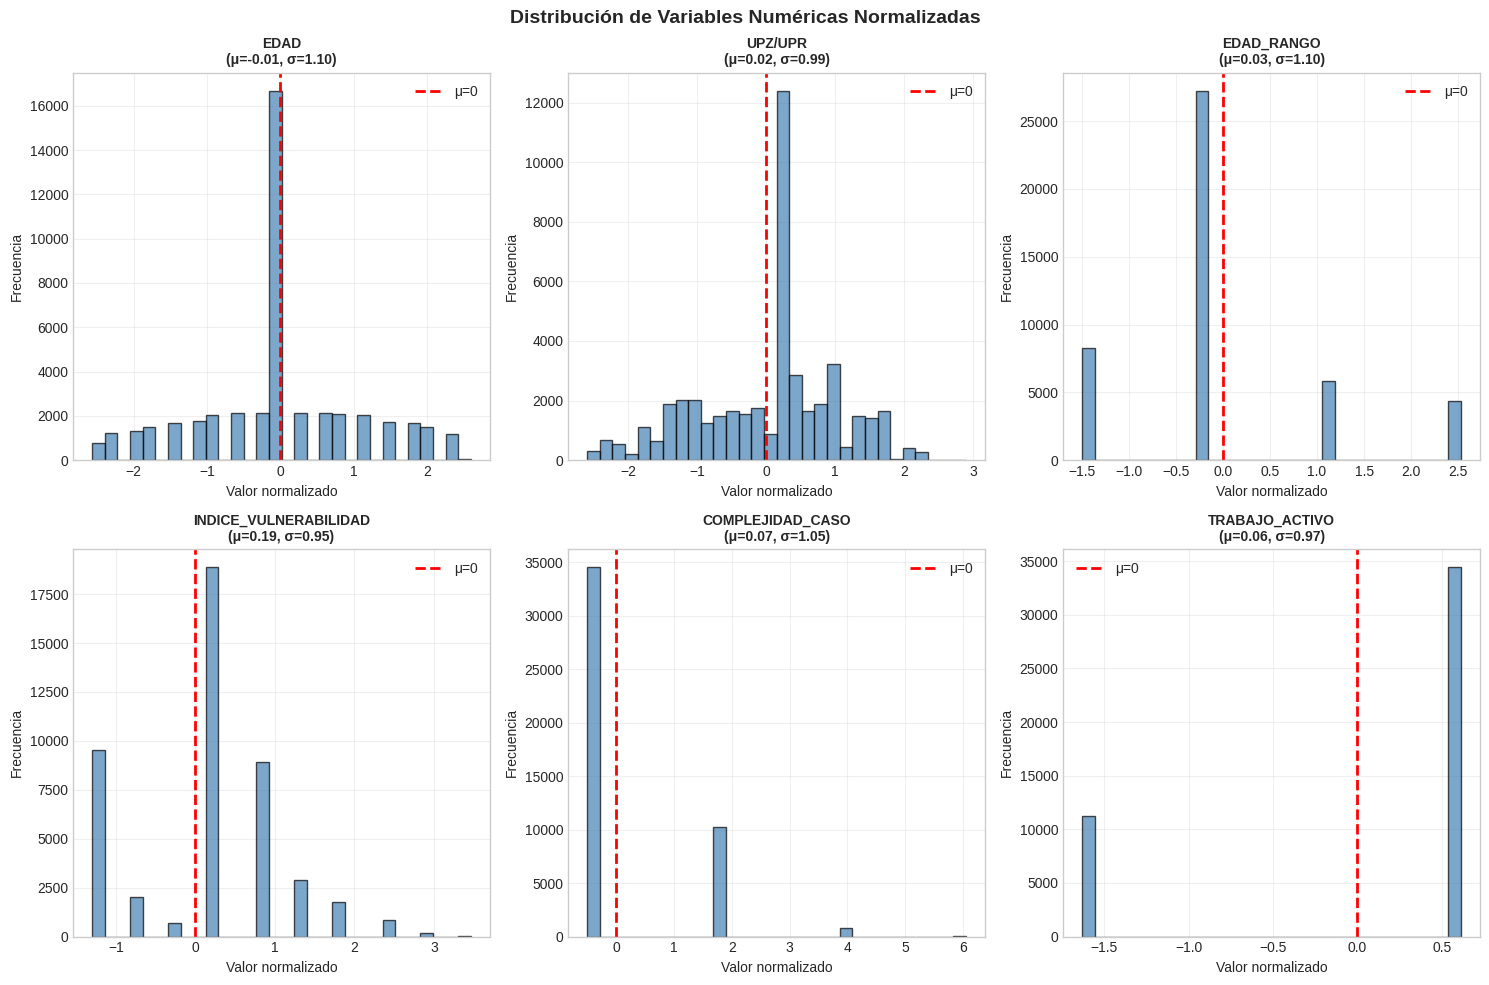

In [103]:
# ==============================================================================
# 12. VISUALIZACIONES DE VERIFICACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print("📊 VISUALIZACIONES DE VERIFICACIÓN")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Graficar las primeras 6 variables numéricas
vars_to_plot = list(scaled_df.columns[:6])

for idx, col in enumerate(vars_to_plot):
    if col in datos_preparados.columns:
        axes[idx].hist(datos_preparados[col], bins=30, color='steelblue',
                      edgecolor='black', alpha=0.7)
        axes[idx].axvline(0, color='red', linestyle='--', linewidth=2,
                         label=f'μ=0')
        axes[idx].set_title(f'{col}\n(μ={datos_preparados[col].mean():.2f}, σ={datos_preparados[col].std():.2f})',
                           fontsize=10, fontweight='bold')
        axes[idx].set_xlabel('Valor normalizado')
        axes[idx].set_ylabel('Frecuencia')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)

plt.suptitle('Distribución de Variables Numéricas Normalizadas',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [104]:
# ==============================================================================
# 13. EXPORTACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

# Crear carpeta si no existe
if not os.path.exists(ruta_salida):
    os.makedirs(ruta_salida)

# Archivo ÚNICO con TODO
print(f"\n📦 Exportando dataset completo...")
csv_completo = ruta_salida + "datos_preparados_final.csv.gz"

try:
    datos_preparados.to_csv(csv_completo, index=False, compression='gzip')

    # Verificar tamaño
    tamanio_mb = os.path.getsize(csv_completo) / 1024**2

    print(f"✅ Archivo exportado exitosamente:")
    print(f"   📁 {csv_completo}")
    print(f"   📊 Shape: {datos_preparados.shape[0]:,} × {datos_preparados.shape[1]:,}")
    print(f"   💾 Tamaño: {tamanio_mb:.2f} MB")

except Exception as e:
    print(f"❌ Error al exportar: {e}")

# Exportar metadatos
print(f"\n📋 Exportando metadatos...")
metadata = pd.DataFrame([{
    'fecha': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'registros': datos_preparados.shape[0],
    'features_totales': datos_preparados.shape[1],
    'features_numericas': scaled_df.shape[1],
    'features_categoricas_onehot': encoded_df.shape[1],
    'variables_numericas_creadas': len(nuevas_numericas),
    'tamanio_mb': tamanio_mb
}])

metadata.to_excel(ruta_salida + "metadata_preparacion.xlsx", index=False)
print(f"✅ Metadatos guardados")


💾 EXPORTACIÓN DE RESULTADOS

📦 Exportando dataset completo...
✅ Archivo exportado exitosamente:
   📁 /content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_final.csv.gz
   📊 Shape: 45,661 × 184
   💾 Tamaño: 0.72 MB

📋 Exportando metadatos...
✅ Metadatos guardados


In [105]:
# ==============================================================================
# 14. RESUMEN EJECUTIVO FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("🎯 RESUMEN EJECUTIVO - FASE DATA PREPARATION COMPLETADA")
print("=" * 80)

print(f"""
✅ PROCESO COMPLETADO EXITOSAMENTE

📊 DATASET FINAL:
   • Registros: {datos_preparados.shape[0]:,}
   • Features TOTALES: {datos_preparados.shape[1]:,}
      ├─ Numéricas normalizadas: {scaled_df.shape[1]}
      └─ Categóricas (One-Hot): {encoded_df.shape[1]:,}

🔨 TRANSFORMACIONES APLICADAS:
   ✓ Feature Engineering: {len(nuevas_numericas)} variables creadas
   ✓ Imputación de valores faltantes: Completada
   ✓ Normalización (StandardScaler): {scaled_df.shape[1]} variables
   ✓ One-Hot Encoding: {len(cat_cols)} variables → {encoded_df.shape[1]:,} features
   ✓ Eliminación de duplicados: {duplicados:,} registros

✅ CALIDAD:
   ✓ Valores NaN: 0
   ✓ Valores infinitos: 0
   ✓ Normalización verificada: μ ≈ 0, σ

PRÓXIMO PASO: Modeling
""")
print("=" * 80)
print("✓ LISTO PARA FASE 4: MODELING")
print("=" * 80)


🎯 RESUMEN EJECUTIVO - FASE DATA PREPARATION COMPLETADA

✅ PROCESO COMPLETADO EXITOSAMENTE

📊 DATASET FINAL:
   • Registros: 45,661
   • Features TOTALES: 184
      ├─ Numéricas normalizadas: 7
      └─ Categóricas (One-Hot): 177

🔨 TRANSFORMACIONES APLICADAS:
   ✓ Feature Engineering: 5 variables creadas
   ✓ Imputación de valores faltantes: Completada
   ✓ Normalización (StandardScaler): 7 variables
   ✓ One-Hot Encoding: 22 variables → 177 features
   ✓ Eliminación de duplicados: 10,812 registros

✅ CALIDAD:
   ✓ Valores NaN: 0
   ✓ Valores infinitos: 0
   ✓ Normalización verificada: μ ≈ 0, σ 

PRÓXIMO PASO: Modeling 

✓ LISTO PARA FASE 4: MODELING


In [106]:
# ==============================================================================
# 13. ELIMINACIÓN DE DUPLICADOS
# ==============================================================================

print("\n" + "=" * 80)
print("🗑️  ELIMINACIÓN DE DUPLICADOS")
print("=" * 80)

duplicados_antes = datos_preparados.duplicated().sum()
print(f"\nRegistros duplicados detectados: {duplicados_antes:,} ({duplicados_antes/len(datos_preparados)*100:.2f}%)")

if duplicados_antes > 0:
    datos_preparados = datos_preparados.drop_duplicates(keep='first').reset_index(drop=True)
    duplicados_despues = datos_preparados.duplicated().sum()
    print(f"Duplicados eliminados: {duplicados_antes:,}")
    print(f"\n✅ Dataset final: {datos_preparados.shape[0]:,} registros únicos")
    print(f"Dimensiones finales: {datos_preparados.shape}")
else:
    print("✅ No hay duplicados")


🗑️  ELIMINACIÓN DE DUPLICADOS

Registros duplicados detectados: 0 (0.00%)
✅ No hay duplicados


In [107]:
# ==============================================================================
# 14. EXPORTACIÓN
# ==============================================================================

print("\n" + "=" * 80)
print("💾 EXPORTACIÓN DE RESULTADOS")
print("=" * 80)

ruta_salida = "/content/drive/MyDrive/Python/Proyecto NNA/"

if not os.path.exists(ruta_salida):
    os.makedirs(ruta_salida)

try:
    # Guardar dataset completo
    csv_completo = ruta_salida + "datos_preparados_completo.csv.gz"
    datos_preparados.to_csv(csv_completo, index=False, compression='gzip')
    print(f"\n✅ Dataset completo: {csv_completo}")

    # Guardar solo numéricas
    csv_numerico = ruta_salida + "datos_preparados_numericos.csv"
    scaled_df.to_csv(csv_numerico, index=False)
    print(f"✅ Dataset numérico: {csv_numerico}")

    # Metadatos
    metadata = {
        'fecha': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'registros': datos_preparados.shape[0],
        'variables_totales': datos_preparados.shape[1],
        'variables_numericas': len(num_cols_reales),
        'variables_categoricas_codificadas': encoded_df.shape[1],
        'componentes_95pct': n_componentes_95
    }

    pd.DataFrame([metadata]).to_csv(ruta_salida + "metadata_preparacion.csv", index=False)
    print(f"✅ Metadatos guardados")

    # Guardar scaler y encoder
    with open(ruta_salida + 'scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)
    with open(ruta_salida + 'encoder.pkl', 'wb') as f:
        pickle.dump(encoder, f)
    print(f"✅ Objetos guardados (scaler.pkl, encoder.pkl)")

except Exception as e:
    print(f"❌ Error: {e}")



💾 EXPORTACIÓN DE RESULTADOS

✅ Dataset completo: /content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_completo.csv.gz
✅ Dataset numérico: /content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_numericos.csv
✅ Metadatos guardados
✅ Objetos guardados (scaler.pkl, encoder.pkl)


In [108]:
# ==============================================================================
# 15. RESUMEN FINAL
# ==============================================================================

print("\n" + "=" * 80)
print("🎯 RESUMEN FINAL - FASE DATA PREPARATION")
print("=" * 80)

print(f"""
✅ PROCESO COMPLETADO

DIMENSIONES FINALES:
   • Registros: {datos_preparados.shape[0]:,}
   • Variables: {datos_preparados.shape[1]:,}
   • Numéricas: {len(num_cols_reales)}
   • Categóricas codificadas: {encoded_df.shape[1]:,}

TRANSFORMACIONES:
   ✓ Exclusión de variables >50% faltantes
   ✓ Imputación de valores faltantes
   ✓ {len(nuevas_variables)} nuevas variables generadas
   ✓ Codificación One-Hot
   ✓ Estandarización

CALIDAD:
   ✓ NaN finales: {datos_preparados.isna().sum().sum()}
   ✓ Dataset listo para clustering

""")

print("=" * 80)
print("✓ LISTO PARA FASE 4: MODELING")
print("=" * 80)



🎯 RESUMEN FINAL - FASE DATA PREPARATION

✅ PROCESO COMPLETADO

DIMENSIONES FINALES:
   • Registros: 45,661
   • Variables: 184
   • Numéricas: 5
   • Categóricas codificadas: 177

TRANSFORMACIONES:
   ✓ Exclusión de variables >50% faltantes
   ✓ Imputación de valores faltantes
   ✓ 2 nuevas variables generadas
   ✓ Codificación One-Hot
   ✓ Estandarización

CALIDAD:
   ✓ NaN finales: 0
   ✓ Dataset listo para clustering

PRÓXIMO PASO: Modeling (K-Means, DBSCAN, Jerárquico)

✓ LISTO PARA FASE 4: MODELING


In [109]:
import pandas as pd

# Cargar el archivo COMPLETO
ruta = '/content/drive/MyDrive/Python/Proyecto NNA/datos_preparados_completo.csv.gz'
datos_completo = pd.read_csv(ruta, compression='gzip')

print(f"Shape del archivo completo: {datos_completo.shape}")
print(f"\nPrimeras 10 columnas:")
print(datos_completo.columns[:10].tolist())
print(f"\nÚltimas 10 columnas:")
print(datos_completo.columns[-10:].tolist())
print(f"\nTipos de columnas:")
print(datos_completo.dtypes.value_counts())

Shape del archivo completo: (45661, 184)

Primeras 10 columnas:
['EDAD', 'UPZ/UPR', 'EDAD_RANGO', 'INDICE_VULNERABILIDAD', 'COMPLEJIDAD_CASO', 'TRABAJO_ACTIVO', 'ANTIGUEDAD_DIAS', 'Base_Origen_MARZO2023_NOVI 2024', 'Base_Origen_dic24_mar25', 'Base_Origen_marzo_octubre 2021']

Últimas 10 columnas:
['INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO_No', 'INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO_No_reporta', 'INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO_SI', 'INTERVENCIÓN DE NIÑO, NIÑA O ADOLESCENTE QUE TERMINA EL PROCESO_Si', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_NO', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_NO APLICA', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_No', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_No_reporta', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_SI', 'NNA DESVINCULADO DE LA ACTIVIDAD LABORAL_Si']

Tipos de columnas:
float64    184
Name: count, dtype: int64
